<a href="https://colab.research.google.com/github/DGP2020/r5a_ailab/blob/main/ml_lab_9july.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Load the dataset
file_path = '/content/train_energy_data_unprocessed.csv'
df = pd.read_csv(file_path)

print(f"Dataset '{file_path}' loaded successfully.\n")


df.info()

print(df.head())
print(df.tail())

Dataset '/content/train_energy_data_unprocessed.csv' loaded successfully.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        950 non-null    object 
 1   Square Footage       951 non-null    object 
 2   Number of Occupants  950 non-null    object 
 3   Appliances Used      950 non-null    object 
 4   Average Temperature  950 non-null    float64
 5   Day of Week          950 non-null    object 
 6   Energy Consumption   950 non-null    float64
dtypes: float64(2), object(5)
memory usage: 54.8+ KB
  Building Type Square Footage Number of Occupants Appliances Used  \
0   Residential         7063.0                76.0            10.0   
1    Commercial        44372.0                66.0            45.0   
2    Industrial        19255.0                37.0            17.0   
3   Residential        13265.0       

In [13]:
print(df.dtypes)
rows,cols=df.shape
print(f"{rows} \n {cols}")

Building Type           object
Square Footage          object
Number of Occupants     object
Appliances Used         object
Average Temperature    float64
Day of Week             object
Energy Consumption     float64
dtype: object
1000 
 7


In [26]:

# Convert 'Number of Occupants' to numeric, coercing errors to NaN
df['Number of Occupants'] = pd.to_numeric(df['Number of Occupants'], errors='coerce')
df['Number of Occupants'] = df['Number of Occupants'].fillna(df['Number of Occupants'].mean())
df.isnull().sum()
# Convert 'Energy consumption' to numeric, coercing errors to NaN (if it wasn't already)
df['Energy Consumption'] = pd.to_numeric(df['Energy Consumption'], errors='coerce')
df['Energy Consumption'] = df['Energy Consumption'].fillna(df['Energy Consumption'].median())

df['Average Temperature'] = pd.to_numeric(df['Average Temperature'], errors='coerce')
df['Average Temperature']=df['Average Temperature'].fillna(df['Average Temperature'].mode()[0])

df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()



,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [29]:
df.duplicated()
df.drop_duplicates(inplace=True)


In [35]:
df['Energy Consumption'] = pd.to_numeric(df['Energy Consumption'], errors='coerce')
#handling outliers in consumption
lower_bound = df['Energy Consumption'].quantile(0.01)
upper_bound = df['Energy Consumption'].quantile(0.99)
df['capped Consumption']=df['Energy Consumption'].clip(lower=lower_bound, upper=upper_bound)
df.sample(7)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,capped Consumption
323,Industrial,16741.0,19.000000,27.0,23.89,Weekend,4189.69,4189.69
437,Industrial,17834.0,47.640212,19.0,23.56,Weekday,4363.89,4363.89
741,Commercial,36112.0,17.000000,42.0,28.54,Weekday,4722.90,4722.90
335,Industrial,33839.0,64.000000,11.0,27.67,Weekday,4963.62,4963.62
5,Commercial,37377.0,26.000000,32.0,16.24,Weekend,4687.67,4687.67
644,Industrial,19529.0,85.000000,19.0,28.85,Weekday,4612.22,4612.22
635,Residential,25361.0,77.000000,26.0,24.09,Weekend,3937.59,3937.59


In [38]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
data=df['Energy Consumption']
df['Standard_scale']=StandardScaler().fit_transform(df[['Energy Consumption']])
df['MinMax_scale']=MinMaxScaler().fit_transform(df[['Energy Consumption']])
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption,capped Consumption,Standard_scale,MinMax_scale
0,Residential,7063.0,76.0,10.0,29.84,Weekday,2713.95,2713.95,-0.046808,0.000025
1,Commercial,44372.0,66.0,45.0,16.72,Weekday,5744.99,5744.99,-0.046641,0.000031
2,Industrial,19255.0,37.0,17.0,14.30,Weekend,4101.24,4101.24,-0.046731,0.000028
3,Residential,13265.0,14.0,41.0,32.82,Weekday,3009.14,3009.14,-0.046792,0.000026
4,Commercial,13375.0,26.0,18.0,11.92,Weekday,3279.17,3279.17,-0.046777,0.000027


In [40]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
print("Correlation Matrix:\n", correlation_matrix)

Correlation Matrix:
                      Number of Occupants  Average Temperature  \
Number of Occupants             1.000000             0.008480   
Average Temperature             0.008480             1.000000   
Energy Consumption             -0.012135            -0.004185   
capped Consumption              0.287973            -0.002757   
Standard_scale                 -0.012135            -0.004185   
MinMax_scale                   -0.012135            -0.004185   

                     Energy Consumption  capped Consumption  Standard_scale  \
Number of Occupants           -0.012135            0.287973       -0.012135   
Average Temperature           -0.004185           -0.002757       -0.004185   
Energy Consumption             1.000000            0.102910        1.000000   
capped Consumption             0.102910            1.000000        0.102910   
Standard_scale                 1.000000            0.102910        1.000000   
MinMax_scale                   1.000000          

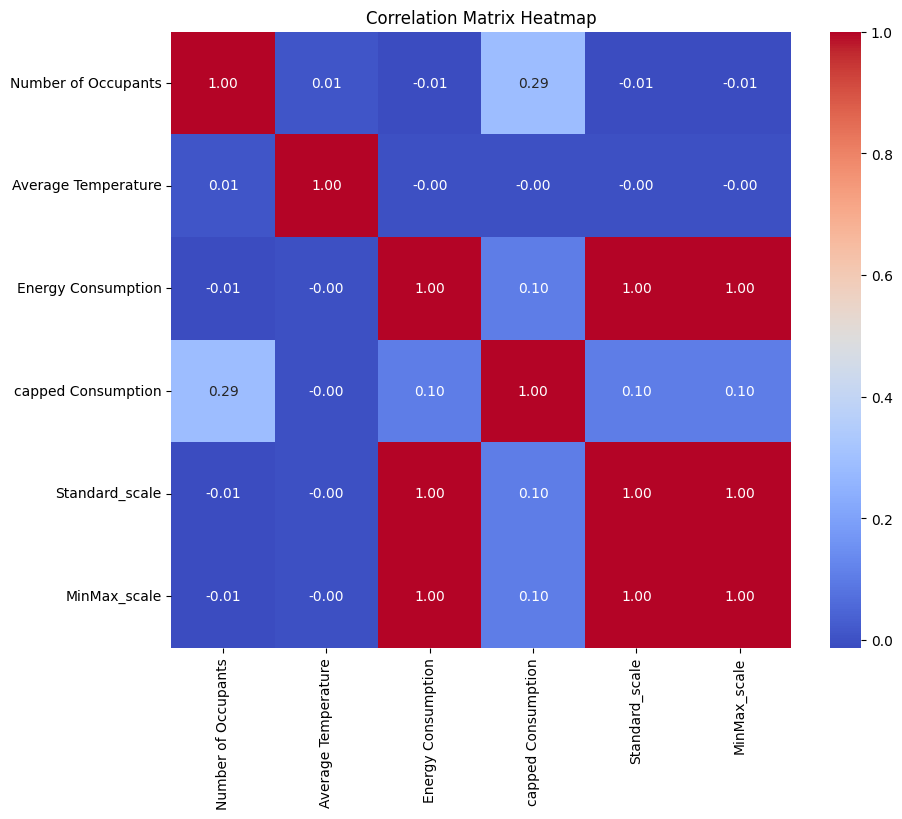

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()